In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.dataset import generate_ou_process, SequenceDataset

In [3]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

gamma_values = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
num_train_trajectories = 5000
num_test_trajectories = 500
epochs = 5
batch_size = 64
learning_rate = 0.001
mean_min, mean_max = -1.5, 1.5

Using device: cpu


In [4]:
def generate_multi_theta_data(num_trajectories, gamma, mean_min, mean_max, cfg):
    random_thetas = np.random.exponential(scale=1.0/gamma, size=num_trajectories)
    random_means = np.random.uniform(mean_min, mean_max, num_trajectories)
    
    all_trajectories = []
    all_means = []
    all_thetas = []
    
    for theta, mu in zip(random_thetas, random_means):
        traj = generate_ou_process(
            batch_size=1,
            time_steps=cfg['generation']['total_time_steps'],
            theta=float(theta),
            mu=float(mu),
            sigma=cfg['physics']['sigma'],
            dt=cfg['physics']['dt']
        )
        all_trajectories.append(traj)
        all_means.append(mu)
        all_thetas.append(theta)
    
    all_trajectories = torch.cat(all_trajectories, dim=0)
    all_means = torch.tensor(all_means, dtype=torch.float32)
    all_thetas = torch.tensor(all_thetas, dtype=torch.float32)
    
    return all_trajectories, all_means, all_thetas

In [5]:
def train_model(trajectories, means, cfg, epochs, batch_size, learning_rate, device):
    dataset = TensorDataset(trajectories, means.unsqueeze(1))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = SimpleTransformer(**cfg['architecture'])
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_Y in loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            preds, _ = model(batch_X)
            pred_mean = preds[:, -1, :]
            loss = criterion(pred_mean, batch_Y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    return model

In [6]:
def evaluate_model(model, trajectories, true_means, device):
    model.eval()
    predicted_means = []
    
    with torch.no_grad():
        for i in range(len(trajectories)):
            traj = trajectories[i:i+1].to(device)
            pred, _ = model(traj)
            pred_mean = pred[:, -1, :].squeeze().cpu().item()
            predicted_means.append(pred_mean)
    
    predicted_means = np.array(predicted_means)
    true_means_np = true_means.numpy()
    
    r2 = r2_score(true_means_np, predicted_means)
    return r2, predicted_means

In [7]:
r2_scores = []

for gamma in gamma_values:
    print(f"\n{'='*50}")
    print(f"Gamma = {gamma} (mean theta = {1/gamma:.3f})")
    print(f"{'='*50}")
    
    print("Generating training data...")
    train_trajs, train_means, train_thetas = generate_multi_theta_data(
        num_train_trajectories, gamma, mean_min, mean_max, cfg
    )
    
    print("Generating test data...")
    test_trajs, test_means, test_thetas = generate_multi_theta_data(
        num_test_trajectories, gamma, mean_min, mean_max, cfg
    )
    
    print(f"Training model for {epochs} epochs...")
    model = train_model(train_trajs, train_means, cfg, epochs, batch_size, learning_rate, device)
    
    print("Evaluating model...")
    r2, _ = evaluate_model(model, test_trajs, test_means, device)
    r2_scores.append(r2)
    
    print(f"R² = {r2:.4f}")


Gamma = 0.5 (mean theta = 2.000)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.9591

Gamma = 1.0 (mean theta = 1.000)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.9518

Gamma = 2.0 (mean theta = 0.500)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.9400

Gamma = 5.0 (mean theta = 0.200)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.8256

Gamma = 10.0 (mean theta = 0.100)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.8241

Gamma = 20.0 (mean theta = 0.050)
Generating training data...
Generating test data...
Training model for 5 epochs...
Evaluating model...
R² = 0.7300

Gamma = 50.0 (mean theta = 0.020)
Generating training data...
Generating test data...
Training model fo

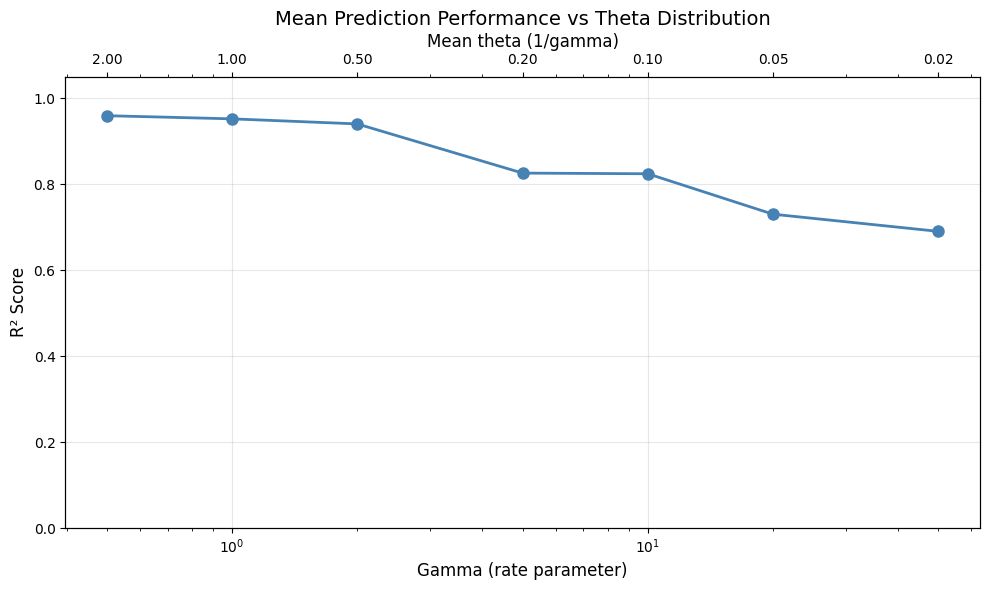

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(gamma_values, r2_scores, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Gamma (rate parameter)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Mean Prediction Performance vs Theta Distribution', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
mean_thetas = [1/g for g in gamma_values]
ax2.set_xticks(gamma_values)
ax2.set_xticklabels([f'{1/g:.2f}' for g in gamma_values])
ax2.set_xlabel('Mean theta (1/gamma)', fontsize=12)

plt.tight_layout()
plt.show()

In [9]:
results_df = {
    'gamma': gamma_values,
    'mean_theta': [1/g for g in gamma_values],
    'r2_score': r2_scores
}

print("\nSummary:")
print("-" * 40)
print(f"{'Gamma':>10} {'Mean θ':>10} {'R²':>10}")
print("-" * 40)
for g, mt, r2 in zip(gamma_values, results_df['mean_theta'], r2_scores):
    print(f"{g:>10.1f} {mt:>10.3f} {r2:>10.4f}")


Summary:
----------------------------------------
     Gamma     Mean θ         R²
----------------------------------------
       0.5      2.000     0.9591
       1.0      1.000     0.9518
       2.0      0.500     0.9400
       5.0      0.200     0.8256
      10.0      0.100     0.8241
      20.0      0.050     0.7300
      50.0      0.020     0.6901
